# IPL Sentiment Analysis Project
## Optimal vectorizer and classifier notebook



Dataset source used:

`https://raw.githubusercontent.com/HimanshuKhale/ipl_sentiment/refs/heads/main/ipl_sentiment_small_dataset.csv`

AND

`https://raw.githubusercontent.com/HimanshuKhale/ipl_sentiment/refs/heads/main/ipl_300R_indian_english_sentiment_dataset.csv`



In [64]:
# ============================================================
# STEP 0: Install/import libraries
# ============================================================

import json
import time
import os
import warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [65]:
# ============================================================
# STEP 1: Load the 80-row dataset from GitHub
# ============================================================

DATA_URL_80R = "https://raw.githubusercontent.com/HimanshuKhale/ipl_sentiment/main/ipl_sentiment_small_dataset.csv"

LOCAL_DATA_PATH_80R = "ipl_sentiment_small_dataset.csv"

def load_dataset_from_github_or_local(url, local_path):
    try:
        df = pd.read_csv(url)
        print("Loaded dataset from GitHub:", url)
        return df
    except Exception as github_error:
        print("Could not load from GitHub. Trying local file...")
        print("GitHub error:", github_error)
        if Path(local_path).exists():
            df = pd.read_csv(local_path)
            print("Loaded local dataset:", local_path)
            return df
        raise FileNotFoundError(
            "Dataset could not be loaded from GitHub or local file. "
            "Please download the CSV and put it next to this notebook."
        )

df_80 = load_dataset_from_github_or_local(DATA_URL_80R, LOCAL_DATA_PATH_80R)

print("Shape:", df_80.shape)
display(df_80.head())
print("Columns:", list(df_80.columns))

Loaded dataset from GitHub: https://raw.githubusercontent.com/HimanshuKhale/ipl_sentiment/main/ipl_sentiment_small_dataset.csv
Shape: (80, 4)


,post_id,statement,subject_keyword,sentiment
0,1,"RCB finally played like champions today, the b...",RCB,positive
1,2,RCB fans deserve better than another middle or...,RCB,negative
2,3,RCB's batting was decent but the fielding stil...,RCB,neutral
3,4,Virat's energy makes RCB matches feel electric...,RCB,positive
4,5,"RCB again lost control in the death overs, sam...",RCB,negative


Columns: ['post_id', 'statement', 'subject_keyword', 'sentiment']


In [66]:
# ============================================================
# STEP 2: Clean and standardize the dataset
# ============================================================

required_columns = ["statement", "subject_keyword", "sentiment"]

missing = [col for col in required_columns if col not in df_80.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Your dataset must have {required_columns}")

df_80 = df_80.dropna(subset=required_columns).copy()
df_80["statement"] = df_80["statement"].astype(str)
df_80["subject_keyword"] = df_80["subject_keyword"].astype(str)
df_80["sentiment"] = df_80["sentiment"].astype(str).str.lower().str.strip()

df_80["model_text"] = df_80["subject_keyword"] + " [SEP] " + df_80["statement"]

print("Cleaned shape:", df_80.shape)
print("\nSentiment distribution:")
display(df_80["sentiment"].value_counts())

print("\nTeam/keyword distribution:")
display(df_80["subject_keyword"].value_counts())

display(df_80[["model_text", "sentiment"]].head())

Cleaned shape: (80, 5)

Sentiment distribution:


,count
sentiment,
positive,28
negative,26
neutral,26



Team/keyword distribution:


,count
subject_keyword,
RCB,8
MI,8
CSK,8
KKR,8
SRH,8
RR,8
DC,8
PBKS,8
GT,8


,model_text,sentiment
0,RCB [SEP] RCB finally played like champions to...,positive
1,RCB [SEP] RCB fans deserve better than another...,negative
2,RCB [SEP] RCB's batting was decent but the fie...,neutral
3,RCB [SEP] Virat's energy makes RCB matches fee...,positive
4,RCB [SEP] RCB again lost control in the death ...,negative


In [67]:
# ============================================================
# STEP 3: Create train/test split for the 80R dataset
# ============================================================

X = df_80["model_text"]
y = df_80["sentiment"]

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train_80))
print("Testing rows:", len(X_test_80))
print("\nTrain label distribution:")
display(y_train_80.value_counts())
print("\nTest label distribution:")
display(y_test_80.value_counts())

Training rows: 60
Testing rows: 20

Train label distribution:


,count
sentiment,
positive,21
neutral,20
negative,19



Test label distribution:


,count
sentiment,
positive,7
negative,7
neutral,6


# STEP 4: Beginner-friendly recipe system

You do **not** need to write complex registration code.

You only need to call:

```python
add_vectorizer(...)
add_classifier(...)
```

Each vectorizer/classifier becomes a **recipe**.  
The notebook will later convert recipes into real sklearn objects.

A recipe has:

- `id`: short unique name
- `name`: readable name
- `family`: category, such as `count`, `tfidf_word`, `tfidf_char`, `hashing`
- `type`: sklearn class name
- `params`: settings
- `notes`: why you chose it
- `complexity`: `low`, `medium`, or `high`

In [68]:
# ============================================================
# STEP 4A: Helper functions for adding recipes
# ============================================================

vectorizer_recipes = []
classifier_recipes = []

def add_vectorizer(id, name, family, type, params=None, notes="", complexity="low"):
    """
    Add a vectorizer recipe.

    Example:
    add_vectorizer(
        id="tfidf_word_1_2",
        name="TF-IDF Word 1-2 grams",
        family="tfidf_word",
        type="TfidfVectorizer",
        params={"ngram_range": (1, 2), "max_features": 3000},
        notes="Good baseline for short text.",
        complexity="low"
    )
    """
    if params is None:
        params = {}
    vectorizer_recipes.append({
        "id": id,
        "name": name,
        "family": family,
        "type": type,
        "params": params,
        "notes": notes,
        "complexity": complexity,
    })

def add_classifier(id, name, family, type, params=None, notes="", complexity="low"):
    """
    Add a classifier recipe.

    Example:
    add_classifier(
        id="logreg_balanced",
        name="Logistic Regression Balanced",
        family="linear",
        type="LogisticRegression",
        params={"max_iter": 1000, "class_weight": "balanced"},
        notes="Strong simple classifier for sparse text.",
        complexity="low"
    )
    """
    if params is None:
        params = {}
    classifier_recipes.append({
        "id": id,
        "name": name,
        "family": family,
        "type": type,
        "params": params,
        "notes": notes,
        "complexity": complexity,
    })

print("Helper functions are ready.")

Helper functions are ready.


In [69]:
# ============================================================
# STEP 4B: Adding vectorizers
# ============================================================

add_vectorizer(
    id="count_basic",
    name="CountVectorizer Basic",
    family="count",
    type="CountVectorizer",
    params={
        "lowercase": True,
        "max_features": 3000
    },
    notes="Simple frequency baseline. Good for seeing whether word counts are enough.",
    complexity="low"
)

add_vectorizer(
    id="tfidf_char_3_5",
    name="TF-IDF Character 3-5 grams",
    family="tfidf_char",
    type="TfidfVectorizer",
    params={
        "analyzer": "char",
        "ngram_range": (3, 5),
        "max_features": 5000
    },
    notes="Useful for typos, Hinglish, team abbreviations, and social media spelling.",
    complexity="medium"
)

add_vectorizer(
    id="hashing_word",
    name="HashingVectorizer Word",
    family="hashing",
    type="HashingVectorizer",
    params={
        "alternate_sign": False,
        "n_features": 2048,
        "lowercase": True
    },
    notes="Scalable vectorizer. Does not store vocabulary, useful for bigger datasets.",
    complexity="medium"
)

add_vectorizer(
    id="tfidf_word_1_1",
    name="TF-IDF Word Unigram",
    family="tfidf_word",
    type="TfidfVectorizer",
    params={
        "lowercase": True,
        "ngram_range": (1,1),
        "max_features": 3000
    },
    notes="Pure unigram TF-IDF baseline.",
    complexity="low"
)


print(f"Total vectorizers added: {len(vectorizer_recipes)}")
pd.DataFrame(vectorizer_recipes)

Total vectorizers added: 4


,id,name,family,type,params,notes,complexity
0,count_basic,CountVectorizer Basic,count,CountVectorizer,"{'lowercase': True, 'max_features': 3000}",Simple frequency baseline. Good for seeing whe...,low
1,tfidf_char_3_5,TF-IDF Character 3-5 grams,tfidf_char,TfidfVectorizer,"{'analyzer': 'char', 'ngram_range': (3, 5), 'm...","Useful for typos, Hinglish, team abbreviations...",medium
2,hashing_word,HashingVectorizer Word,hashing,HashingVectorizer,"{'alternate_sign': False, 'n_features': 2048, ...",Scalable vectorizer. Does not store vocabulary...,medium
3,tfidf_word_1_1,TF-IDF Word Unigram,tfidf_word,TfidfVectorizer,"{'lowercase': True, 'ngram_range': (1, 1), 'ma...",Pure unigram TF-IDF baseline.,low


In [70]:
# ============================================================
# STEP 4C: Adding classifiers
# ============================================================

add_classifier(
    id="logreg_balanced",
    name="Logistic Regression Balanced",
    family="linear",
    type="LogisticRegression",
    params={
        "max_iter": 1000,
        "class_weight": "balanced",
        "random_state": RANDOM_STATE
    },
    notes="Simple, explainable, and often strong for TF-IDF features.",
    complexity="low"
)

add_classifier(
    id="linear_svc",
    name="LinearSVC",
    family="margin_based",
    type="LinearSVC",
    params={
        "random_state": RANDOM_STATE
    },
    notes="Strong classical classifier for high-dimensional text data.",
    complexity="medium"
)


add_classifier(
    id="complement_nb",
    name="Complement Naive Bayes",
    family="probabilistic",
    type="ComplementNB",
    params={},
    notes="Often stronger than MultinomialNB for sparse text classification.",
    complexity="low"
)

add_classifier(
    id="multinomial_nb",
    name="Multinomial Naive Bayes",
    family="probabilistic",
    type="MultinomialNB",
    params={},
    notes="Very fast and strong baseline for text classification.",
    complexity="low"
)

print(f"Total classifiers added: {len(classifier_recipes)}")
pd.DataFrame(classifier_recipes)

Total classifiers added: 4


,id,name,family,type,params,notes,complexity
0,logreg_balanced,Logistic Regression Balanced,linear,LogisticRegression,"{'max_iter': 1000, 'class_weight': 'balanced',...","Simple, explainable, and often strong for TF-I...",low
1,linear_svc,LinearSVC,margin_based,LinearSVC,{'random_state': 42},Strong classical classifier for high-dimension...,medium
2,complement_nb,Complement Naive Bayes,probabilistic,ComplementNB,{},Often stronger than MultinomialNB for sparse t...,low
3,multinomial_nb,Multinomial Naive Bayes,probabilistic,MultinomialNB,{},Very fast and strong baseline for text classif...,low


In [71]:
# ============================================================
# STEP 5: Validate diversity rules
# ============================================================

def validate_recipe_diversity(vectorizers, classifiers):
    messages = []

    v_families = sorted(set(v["family"] for v in vectorizers))
    c_families = sorted(set(c["family"] for c in classifiers))
    heavy_classifiers = [c for c in classifiers if c.get("complexity") == "high"]

    messages.append(f"Vectorizer count: {len(vectorizers)}")
    messages.append(f"Classifier count: {len(classifiers)}")
    messages.append(f"Vectorizer families: {v_families}")
    messages.append(f"Classifier families: {c_families}")
    messages.append(f"Heavy classifiers: {[c['id'] for c in heavy_classifiers]}")

    warnings = []
    if len(vectorizers) < 4:
        warnings.append("Add at least 4 vectorizers before final submission.")
    if len(classifiers) < 4:
        warnings.append("Add at least 4 classifiers before final submission.")
    if len(v_families) < 3:
        warnings.append("Use at least 3 different vectorizer families.")
    if len(c_families) < 3:
        warnings.append("Use at least 3 different classifier families.")
    if len(heavy_classifiers) > 1:
        warnings.append("Use maximum 1 heavy classifier.")

    return messages, warnings

messages, warnings_list = validate_recipe_diversity(vectorizer_recipes, classifier_recipes)

print("\n".join(messages))
if warnings_list:
    print("\nWarnings:")
    for w in warnings_list:
        print("-", w)
else:
    print("\nDiversity check passed.")

Vectorizer count: 4
Classifier count: 4
Vectorizer families: ['count', 'hashing', 'tfidf_char', 'tfidf_word']
Classifier families: ['linear', 'margin_based', 'probabilistic']
Heavy classifiers: []

Diversity check passed.


In [72]:
# ============================================================
# STEP 6: Build actual sklearn objects from recipes
# ============================================================

VECTORIZER_CLASSES = {
    "CountVectorizer": CountVectorizer,
    "TfidfVectorizer": TfidfVectorizer,
    "HashingVectorizer": HashingVectorizer,
}

CLASSIFIER_CLASSES = {
    "MultinomialNB": MultinomialNB,
    "ComplementNB": ComplementNB,
    "LogisticRegression": LogisticRegression,
    "LinearSVC": LinearSVC,
    "SGDClassifier": SGDClassifier,
    "RandomForestClassifier": RandomForestClassifier,
}

def clean_params(params):
    params = deepcopy(params)
    if "ngram_range" in params and isinstance(params["ngram_range"], list):
        params["ngram_range"] = tuple(params["ngram_range"])
    return params

def build_vectorizer(recipe):
    cls = VECTORIZER_CLASSES[recipe["type"]]
    return cls(**clean_params(recipe.get("params", {})))

def build_classifier(recipe):
    cls = CLASSIFIER_CLASSES[recipe["type"]]
    return cls(**clean_params(recipe.get("params", {})))

def make_pipeline(vectorizer_recipe, classifier_recipe):
    return Pipeline([
        ("vectorizer", build_vectorizer(vectorizer_recipe)),
        ("classifier", build_classifier(classifier_recipe)),
    ])

print("Factory functions are ready.")

Factory functions are ready.


In [73]:
# ============================================================
# STEP 7: Train every vectorizer × classifier combination on 80R
# ============================================================

def estimate_model_size_kb(model, temp_path="temp_pipeline_model.joblib"):
    try:
        joblib.dump(model, temp_path)
        size_kb = os.path.getsize(temp_path) / 1024
        os.remove(temp_path)
        return size_kb
    except Exception:
        return np.nan

def complexity_penalty(v_recipe, c_recipe):
    levels = {"low": 0, "medium": 1, "high": 2}
    return levels.get(v_recipe.get("complexity", "low"), 0) + levels.get(c_recipe.get("complexity", "low"), 0)

def run_single_pipeline(v_recipe, c_recipe, X_train, X_test, y_train, y_test):
    result = {
        "vectorizer_id": v_recipe["id"],
        "vectorizer_name": v_recipe["name"],
        "vectorizer_family": v_recipe["family"],
        "vectorizer_complexity": v_recipe.get("complexity", "low"),
        "classifier_id": c_recipe["id"],
        "classifier_name": c_recipe["name"],
        "classifier_family": c_recipe["family"],
        "classifier_complexity": c_recipe.get("complexity", "low"),
        "pipeline_id": f"{v_recipe['id']}__{c_recipe['id']}",
    }

    try:
        pipeline = make_pipeline(v_recipe, c_recipe)

        start_train = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - start_train

        start_pred = time.time()
        y_pred = pipeline.predict(X_test)
        pred_time = time.time() - start_pred

        acc = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
        size_kb = estimate_model_size_kb(pipeline)

        # Simple scoring:
        # Performance is important, but efficient/simple models get rewarded too.
        performance_score = (macro_f1 * 60) + (acc * 25) + (weighted_f1 * 15)

        # Efficiency score rewards fast/small models.
        speed_score = max(0, 100 - (train_time * 10) - (pred_time * 100))
        size_score = max(0, 100 - (size_kb / 20)) if not np.isnan(size_kb) else 50
        efficiency_score = (speed_score * 0.6) + (size_score * 0.4)

        # Suitability rewards simpler models unless heavy models strongly outperform.
        penalty = complexity_penalty(v_recipe, c_recipe)
        suitability_score = max(0, 100 - penalty * 15)

        final_score = (
            performance_score * 0.55
            + efficiency_score * 0.20
            + suitability_score * 0.15
            + 100 * 0.10  # basic completion score
        )

        result.update({
            "status": "completed",
            "accuracy": acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "train_time_sec": train_time,
            "prediction_time_sec": pred_time,
            "model_size_kb": size_kb,
            "performance_score": performance_score,
            "efficiency_score": efficiency_score,
            "suitability_score": suitability_score,
            "final_score": final_score,
            "error": "",
        })

    except Exception as e:
        result.update({
            "status": "failed",
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
            "precision_macro": np.nan,
            "recall_macro": np.nan,
            "train_time_sec": np.nan,
            "prediction_time_sec": np.nan,
            "model_size_kb": np.nan,
            "performance_score": 0,
            "efficiency_score": 0,
            "suitability_score": 0,
            "final_score": 0,
            "error": str(e),
        })

    return result

all_results = []
total_runs = len(vectorizer_recipes) * len(classifier_recipes)
print(f"Running {total_runs} pipelines...")

for v in vectorizer_recipes:
    for c in classifier_recipes:
        print(f"Training: {v['id']} + {c['id']}")
        result = run_single_pipeline(v, c, X_train_80, X_test_80, y_train_80, y_test_80)
        all_results.append(result)

results_80 = pd.DataFrame(all_results).sort_values("final_score", ascending=False).reset_index(drop=True)
results_80.insert(0, "rank", range(1, len(results_80) + 1))

print("Done.")
display(results_80)

Running 16 pipelines...
Training: count_basic + logreg_balanced
Training: count_basic + linear_svc
Training: count_basic + complement_nb
Training: count_basic + multinomial_nb
Training: tfidf_char_3_5 + logreg_balanced
Training: tfidf_char_3_5 + linear_svc
Training: tfidf_char_3_5 + complement_nb
Training: tfidf_char_3_5 + multinomial_nb
Training: hashing_word + logreg_balanced
Training: hashing_word + linear_svc
Training: hashing_word + complement_nb
Training: hashing_word + multinomial_nb
Training: tfidf_word_1_1 + logreg_balanced
Training: tfidf_word_1_1 + linear_svc
Training: tfidf_word_1_1 + complement_nb
Training: tfidf_word_1_1 + multinomial_nb
Done.


,rank,vectorizer_id,vectorizer_name,vectorizer_family,vectorizer_complexity,classifier_id,classifier_name,classifier_family,classifier_complexity,pipeline_id,...,precision_macro,recall_macro,train_time_sec,prediction_time_sec,model_size_kb,performance_score,efficiency_score,suitability_score,final_score,error
0,1,count_basic,CountVectorizer Basic,count,low,complement_nb,Complement Naive Bayes,probabilistic,low,count_basic__complement_nb,...,0.688095,0.714286,0.010295,0.002868,25.864258,69.160714,99.248842,100,82.888161,
1,2,count_basic,CountVectorizer Basic,count,low,logreg_balanced,Logistic Regression Balanced,linear,low,count_basic__logreg_balanced,...,0.666667,0.666667,0.065066,0.002604,16.687500,64.784759,99.119643,100,80.455546,
2,3,tfidf_word_1_1,TF-IDF Word Unigram,tfidf_word,low,logreg_balanced,Logistic Regression Balanced,linear,low,tfidf_word_1_1__logreg_balanced,...,0.614815,0.619048,0.018998,0.002023,19.066406,60.541667,99.383321,100,78.174581,
3,4,hashing_word,HashingVectorizer Word,hashing,medium,multinomial_nb,Multinomial Naive Bayes,probabilistic,low,hashing_word__multinomial_nb,...,0.666667,0.666667,0.010959,0.001713,97.336914,62.308480,97.884739,85,76.596612,
4,5,count_basic,CountVectorizer Basic,count,low,multinomial_nb,Multinomial Naive Bayes,probabilistic,low,count_basic__multinomial_nb,...,0.563492,0.619048,0.010127,0.002892,23.458008,57.518326,99.296541,100,76.494387,
5,6,count_basic,CountVectorizer Basic,count,low,linear_svc,LinearSVC,margin_based,medium,count_basic__linear_svc,...,0.651515,0.611111,0.013383,0.002315,16.511719,60.482323,99.450594,85,75.905397,
6,7,hashing_word,HashingVectorizer Word,hashing,medium,logreg_balanced,Logistic Regression Balanced,linear,low,hashing_word__logreg_balanced,...,0.614815,0.619048,0.037410,0.001826,49.500977,60.541667,98.675985,85,75.783114,
7,8,tfidf_word_1_1,TF-IDF Word Unigram,tfidf_word,low,complement_nb,Complement Naive Bayes,probabilistic,low,tfidf_word_1_1__complement_nb,...,0.496032,0.571429,0.007922,0.001924,28.165039,52.369481,99.273755,100,73.657965,
8,9,tfidf_word_1_1,TF-IDF Word Unigram,tfidf_word,low,linear_svc,LinearSVC,margin_based,medium,tfidf_word_1_1__linear_svc,...,0.600000,0.563492,0.006651,0.001732,18.937500,56.321747,99.477446,85,73.622450,
9,10,hashing_word,HashingVectorizer Word,hashing,medium,complement_nb,Complement Naive Bayes,probabilistic,low,hashing_word__complement_nb,...,0.546296,0.619048,0.007721,0.003705,113.399414,56.831250,97.463399,85,73.499867,


In [74]:
# ============================================================
# STEP 8: Save and inspect 80R results
# ============================================================

results_80.to_csv("results_80R.csv", index=False)
print("Saved: results_80R.csv")

print("\nTop 10 pipelines by final_score:")
display(results_80.head(10)[[
    "rank",
    "pipeline_id",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "train_time_sec",
    "model_size_kb",
    "final_score",
    "status",
]])

print("\nFailed pipelines, if any:")
display(results_80[results_80["status"] == "failed"][["pipeline_id", "error"]])

Saved: results_80R.csv

Top 10 pipelines by final_score:


,rank,pipeline_id,accuracy,macro_f1,weighted_f1,train_time_sec,model_size_kb,final_score,status
0,1,count_basic__complement_nb,0.70,0.690476,0.682143,0.010295,25.864258,82.888161,completed
1,2,count_basic__logreg_balanced,0.65,0.650624,0.633155,0.065066,16.687500,80.455546,completed
2,3,tfidf_word_1_1__logreg_balanced,0.60,0.611111,0.591667,0.018998,19.066406,78.174581,completed
3,4,hashing_word__multinomial_nb,0.65,0.617934,0.598830,0.010959,97.336914,76.596612,completed
4,5,count_basic__multinomial_nb,0.60,0.570437,0.552805,0.010127,23.458008,76.494387,completed
5,6,count_basic__linear_svc,0.60,0.609428,0.594444,0.013383,16.511719,75.905397,completed
6,7,hashing_word__logreg_balanced,0.60,0.611111,0.591667,0.037410,49.500977,75.783114,completed
7,8,tfidf_word_1_1__complement_nb,0.55,0.517749,0.503636,0.007922,28.165039,73.657965,completed
8,9,tfidf_word_1_1__linear_svc,0.55,0.571004,0.554100,0.006651,18.937500,73.622450,completed
9,10,hashing_word__complement_nb,0.60,0.560714,0.545893,0.007721,113.399414,73.499867,completed



Failed pipelines, if any:


,pipeline_id,error


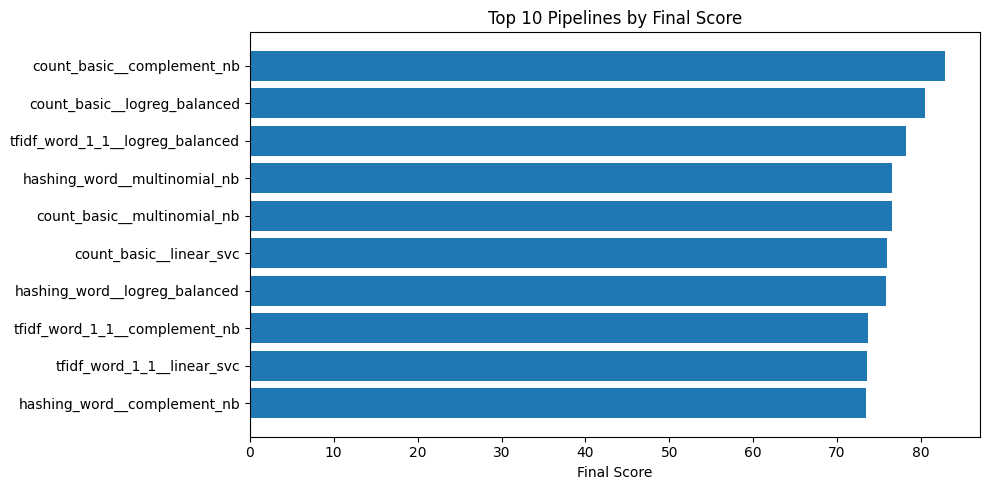

Average performance by vectorizer family:


,macro_f1,accuracy,final_score
vectorizer_family,,,
count,0.630241,0.6375,78.935873
hashing,0.593736,0.6125,74.587798
tfidf_word,0.546098,0.5500,74.261999
tfidf_char,0.426195,0.4500,64.131637


Average performance by classifier family:


,macro_f1,accuracy,final_score
classifier_family,,,
linear,0.584581,0.5875,75.371538
probabilistic,0.526214,0.5500,72.356206
margin_based,0.559261,0.5625,71.833358


In [75]:
# ============================================================
# STEP 9: Visual analytics
# ============================================================

completed = results_80[results_80["status"] == "completed"].copy()

if completed.empty:
    print("No completed models to visualize.")
else:
    top_plot = completed.sort_values("final_score", ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    plt.barh(top_plot["pipeline_id"][::-1], top_plot["final_score"][::-1])
    plt.xlabel("Final Score")
    plt.title("Top 10 Pipelines by Final Score")
    plt.tight_layout()
    plt.show()

    family_perf = completed.groupby("vectorizer_family")[["macro_f1", "accuracy", "final_score"]].mean().sort_values("final_score", ascending=False)
    print("Average performance by vectorizer family:")
    display(family_perf)

    clf_perf = completed.groupby("classifier_family")[["macro_f1", "accuracy", "final_score"]].mean().sort_values("final_score", ascending=False)
    print("Average performance by classifier family:")
    display(clf_perf)

In [76]:
# ============================================================
# STEP 10A: Detailed report for one pipeline
# ============================================================

SELECTED_PIPELINE_ID = results_80.iloc[0]["pipeline_id"]

selected_row = results_80[results_80["pipeline_id"] == SELECTED_PIPELINE_ID].iloc[0]
v_recipe = next(v for v in vectorizer_recipes if v["id"] == selected_row["vectorizer_id"])
c_recipe = next(c for c in classifier_recipes if c["id"] == selected_row["classifier_id"])

pipeline = make_pipeline(v_recipe, c_recipe)
pipeline.fit(X_train_80, y_train_80)
y_pred = pipeline.predict(X_test_80)

print("Selected pipeline:", SELECTED_PIPELINE_ID)
print("\nClassification report:")
print(classification_report(y_test_80, y_pred, zero_division=0))

labels = sorted(y.unique())
cm = confusion_matrix(y_test_80, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"actual_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
display(cm_df)

Selected pipeline: count_basic__complement_nb

Classification report:
              precision    recall  f1-score   support

    negative       0.60      0.43      0.50         7
     neutral       0.75      1.00      0.86         6
    positive       0.71      0.71      0.71         7

    accuracy                           0.70        20
   macro avg       0.69      0.71      0.69        20
weighted avg       0.68      0.70      0.68        20



,pred_negative,pred_neutral,pred_positive
actual_negative,3,2,2
actual_neutral,0,6,0
actual_positive,2,0,5


In [78]:
# ============================================================
# STEP 12A: Load optional 300R dataset
# ============================================================

DATA_URL_300R = "https://raw.githubusercontent.com/iamrehanshaikh2008/ipl-sentiment-pipeline-challenge-rehan/refs/heads/main/ipl_300R_indian_english_sentiment_dataset.csv"
LOCAL_DATA_PATH_300R = "ipl_300R_indian_english_sentiment_dataset.csv"

def load_optional_300R():
    if DATA_URL_300R:
        try:
            df = pd.read_csv(DATA_URL_300R)
            print("Loaded 300R from GitHub:", DATA_URL_300R)
            return df
        except Exception as e:
            print("Could not load DATA_URL_300R:", e)

    if Path(LOCAL_DATA_PATH_300R).exists():
        df = pd.read_csv(LOCAL_DATA_PATH_300R)
        print("Loaded local 300R dataset:", LOCAL_DATA_PATH_300R)
        return df

    print("No 300R dataset found. You can skip the 300R section for now.")
    return None

df_300 = load_optional_300R()

if df_300 is not None:
    if "tweet" in df_300.columns and "statement" not in df_300.columns:
        df_300 = df_300.rename(columns={"tweet": "statement"})

    missing = [col for col in required_columns if col not in df_300.columns]
    if missing:
        raise ValueError(f"300R dataset is missing required columns: {missing}")

    df_300 = df_300.dropna(subset=required_columns).copy()
    df_300["statement"] = df_300["statement"].astype(str)
    df_300["subject_keyword"] = df_300["subject_keyword"].astype(str)
    df_300["sentiment"] = df_300["sentiment"].astype(str).str.lower().str.strip()
    df_300["model_text"] = df_300["subject_keyword"] + " [SEP] " + df_300["statement"]

    print("300R shape:", df_300.shape)
    display(df_300.head())
    display(df_300["sentiment"].value_counts())

Loaded 300R from GitHub: https://raw.githubusercontent.com/iamrehanshaikh2008/ipl-sentiment-pipeline-challenge-rehan/refs/heads/main/ipl_300R_indian_english_sentiment_dataset.csv
300R shape: (300, 5)


,post_id,statement,subject_keyword,sentiment,model_text
0,IPL300R_042,tbh honestly mi bowling was all over the place...,MI,negative,MI [SEP] tbh honestly mi bowling was all over ...
1,IPL300R_197,"ngl bro dc bowling without plan lag rhi thi, ...",DC,negative,DC [SEP] ngl bro dc bowling without plan lag ...
2,IPL300R_109,"ngl bro KKR bowling without plan lag rhi thi, ...",KKR,negative,KKR [SEP] ngl bro KKR bowling without plan lag...
3,IPL300R_119,"dekho KKR ka match dekha, few good moments but...",KKR,neutral,"KKR [SEP] dekho KKR ka match dekha, few good m..."
4,IPL300R_034,bhai MI finally playing like a proper champion...,MI,positive,MI [SEP] bhai MI finally playing like a proper...


,count
sentiment,
negative,100
neutral,100
positive,100


In [79]:
# ============================================================
# STEP 12B: Run pipelines on 300R dataset
# ============================================================

if df_300 is None:
    print("Skipping 300R experiment because no 300R dataset was loaded.")
    results_300 = pd.DataFrame()
else:
    X_300 = df_300["model_text"]
    y_300 = df_300["sentiment"]

    X_train_300, X_test_300, y_train_300, y_test_300 = train_test_split(
        X_300,
        y_300,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_300
    )

    selected_pipeline_ids_for_300R = candidate_shortlist["pipeline_id"].tolist()

    results_300_list = []
    print(f"Running {len(selected_pipeline_ids_for_300R)} shortlisted pipelines on 300R...")

    for pid in selected_pipeline_ids_for_300R:
        row = results_80[results_80["pipeline_id"] == pid].iloc[0]
        v_recipe = next(v for v in vectorizer_recipes if v["id"] == row["vectorizer_id"])
        c_recipe = next(c for c in classifier_recipes if c["id"] == row["classifier_id"])
        print(f"300R training: {pid}")
        result = run_single_pipeline(v_recipe, c_recipe, X_train_300, X_test_300, y_train_300, y_test_300)
        results_300_list.append(result)

    results_300 = pd.DataFrame(results_300_list).sort_values("final_score", ascending=False).reset_index(drop=True)
    results_300.insert(0, "rank_300R", range(1, len(results_300) + 1))
    results_300.to_csv("results_300R.csv", index=False)

    print("Saved: results_300R.csv")
    display(results_300)

Running 9 shortlisted pipelines on 300R...
300R training: count_basic__complement_nb
300R training: count_basic__logreg_balanced
300R training: tfidf_word_1_1__logreg_balanced
300R training: hashing_word__multinomial_nb
300R training: count_basic__multinomial_nb
300R training: count_basic__linear_svc
300R training: hashing_word__logreg_balanced
300R training: tfidf_word_1_1__complement_nb
300R training: tfidf_char_3_5__logreg_balanced
Saved: results_300R.csv


,rank_300R,vectorizer_id,vectorizer_name,vectorizer_family,vectorizer_complexity,classifier_id,classifier_name,classifier_family,classifier_complexity,pipeline_id,...,precision_macro,recall_macro,train_time_sec,prediction_time_sec,model_size_kb,performance_score,efficiency_score,suitability_score,final_score,error
0,1,count_basic,CountVectorizer Basic,count,low,logreg_balanced,Logistic Regression Balanced,linear,low,count_basic__logreg_balanced,...,1.000000,1.000000,0.017001,0.002577,16.125000,100.000000,99.420896,100,99.884179,
1,2,count_basic,CountVectorizer Basic,count,low,multinomial_nb,Multinomial Naive Bayes,probabilistic,low,count_basic__multinomial_nb,...,1.000000,1.000000,0.008910,0.002420,22.754883,100.000000,99.346214,100,99.869243,
2,3,tfidf_word_1_1,TF-IDF Word Unigram,tfidf_word,low,logreg_balanced,Logistic Regression Balanced,linear,low,tfidf_word_1_1__logreg_balanced,...,1.000000,1.000000,0.020788,0.003217,18.457031,100.000000,99.313138,100,99.862628,
3,4,count_basic,CountVectorizer Basic,count,low,complement_nb,Complement Naive Bayes,probabilistic,low,count_basic__complement_nb,...,1.000000,1.000000,0.009923,0.002518,25.129883,100.000000,99.286805,100,99.857361,
4,5,tfidf_word_1_1,TF-IDF Word Unigram,tfidf_word,low,complement_nb,Complement Naive Bayes,probabilistic,low,tfidf_word_1_1__complement_nb,...,1.000000,1.000000,0.009794,0.003070,27.415039,100.000000,99.208731,100,99.841746,
5,6,count_basic,CountVectorizer Basic,count,low,linear_svc,LinearSVC,margin_based,medium,count_basic__linear_svc,...,1.000000,1.000000,0.017934,0.002596,15.949219,100.000000,99.417674,85,97.633535,
6,7,hashing_word,HashingVectorizer Word,hashing,medium,logreg_balanced,Logistic Regression Balanced,linear,low,hashing_word__logreg_balanced,...,0.987179,0.986667,0.022681,0.002731,49.500977,98.666267,98.710042,85,96.758455,
7,8,tfidf_char_3_5,TF-IDF Character 3-5 grams,tfidf_char,medium,logreg_balanced,Logistic Regression Balanced,linear,low,tfidf_char_3_5__logreg_balanced,...,1.000000,1.000000,0.682660,0.042007,285.816406,100.000000,87.667263,85,95.283453,
8,9,hashing_word,HashingVectorizer Word,hashing,medium,multinomial_nb,Multinomial Naive Bayes,probabilistic,low,hashing_word__multinomial_nb,...,0.950142,0.946667,0.008216,0.002609,97.336914,94.657649,97.847438,85,94.381195,


In [83]:
# ============================================================
# STEP 14: Generate JSON submission manifest
# ============================================================

def json_safe(obj):

    if isinstance(obj, tuple):
        return list(obj)
    if isinstance(obj, dict):
        return {k: json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(x) for x in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

STUDENT_NAME = "Rehan Shaikh"
TEAM_NAME = "Group 2"

STUDENT_HYPOTHESIS = (
    "I selected CountVectorizer, HashingVectorizer, TF-IDF Word Unigram, and TF-IDF Character 3–5 Grams to compare different methods of converting text into numerical features."
    "I chose Complement Naive Bayes, Multinomial Naive Bayes, Logistic Regression, and LinearSVC because they are commonly used in text classification and represent different machine learning approaches."
    "By combining these vectorizers and classifiers, I was able to achieve the most optimals and diverse results"
)

best_80_pipeline = results_80.iloc[0].to_dict()

if "results_300" in globals() and isinstance(results_300, pd.DataFrame) and not results_300.empty:
    best_300_pipeline = results_300.iloc[0].to_dict()
else:
    best_300_pipeline = None

submission_manifest = {
    "student_name": "Rehan Shaikh",
    "team_name": "Group 2",
    "task_type": "entity_aware_sentiment_classification",
    "dataset_used_for_initial_experiment": "ipl_sentiment_small_dataset.csv",
    "target_labels": sorted(df_80["sentiment"].unique().tolist()),
    "model_input_format": "subject_keyword + ' [SEP] ' + statement",
    "hypothesis": STUDENT_HYPOTHESIS,
    "final_vectorizers": json_safe(final_vectorizers),
    "final_classifiers": json_safe(final_classifiers),
    "best_80R_pipeline": json_safe(best_80_pipeline),
    "best_300R_pipeline": json_safe(best_300_pipeline),
    "files_expected": [
        "completed_notebook.ipynb",
        "submission_manifest.json",
        "results_80R.csv",
        "results_300R.csv if 300R was used"
    ],
}

print(json.dumps(submission_manifest, indent=2))

with open("submission_manifest.json", "w", encoding="utf-8") as f:
    json.dump(submission_manifest, f, indent=2)

print("\nSaved: submission_manifest.json")

{
  "student_name": "Rehan Shaikh",
  "team_name": "Group 2",
  "task_type": "entity_aware_sentiment_classification",
  "dataset_used_for_initial_experiment": "ipl_sentiment_small_dataset.csv",
  "target_labels": [
    "negative",
    "neutral",
    "positive"
  ],
  "model_input_format": "subject_keyword + ' [SEP] ' + statement",
  "hypothesis": "I selected CountVectorizer, HashingVectorizer, TF-IDF Word Unigram, and TF-IDF Character 3\u20135 Grams to compare different methods of converting text into numerical features.I chose Complement Naive Bayes, Multinomial Naive Bayes, Logistic Regression, and LinearSVC because they are commonly used in text classification and represent different machine learning approaches.By combining these vectorizers and classifiers, I was able to achieve the most optimals and diverse results",
  "final_vectorizers": [
    {
      "id": "count_basic",
      "name": "CountVectorizer Basic",
      "family": "count",
      "type": "CountVectorizer",
      "para

In [85]:
# ============================================================
# OPTIONAL: Save the best 80R pipeline as a pkl
# ============================================================
# This is only for your own practice. The official Django app may retrain models itself.

SAVE_DEMO_BEST_PIPELINE = True

if SAVE_DEMO_BEST_PIPELINE:
    best_row = results_80.iloc[0]
    v_recipe = next(v for v in vectorizer_recipes if v["id"] == best_row["vectorizer_id"])
    c_recipe = next(c for c in classifier_recipes if c["id"] == best_row["classifier_id"])

    best_pipeline = make_pipeline(v_recipe, c_recipe)
    best_pipeline.fit(X, y)

    joblib.dump(best_pipeline, "best_80R_pipeline.pkl")
    print("Saved: demo_best_80R_pipeline.pkl")

    sample_text = "RCB [SEP] rcb batting mast thi but bowling thoda weak lag rhi hai"
    print("Sample prediction:", best_pipeline.predict([sample_text])[0])
else:
    print("Demo pickle saving is off. Set SAVE_DEMO_BEST_PIPELINE = True if needed.")

Saved: demo_best_80R_pipeline.pkl
Sample prediction: neutral
